# 02_Core_Concepts.ipynb

---

# Working Intuition

KNN is based on a simple assumption:

> **Data points that are close to each other are likely to have similar outputs.**

It does **not** try to find a mathematical equation like Linear Regression or Logistic Regression.

Instead, it memorizes the training data and delays all the work until prediction time.

This is why KNN is called a **Lazy Learning Algorithm**.

---

## Intuition with Classification

Suppose our training data looks like this:

```text
Class A (○)

○      ○

       ?

            ●

      ●      ●

Class B (●)
```

The `?` is a new data point.

KNN asks:

1. Which training points are closest?
2. What classes do they belong to?
3. Which class appears the most?

Example (K = 5):

| Neighbor | Class |
| -------- | ----- |
| 1        | ○     |
| 2        | ●     |
| 3        | ○     |
| 4        | ○     |
| 5        | ●     |

Votes:

```text
○ → 3 votes
● → 2 votes
```

Prediction:

```text
Class A (○)
```

---

## Intuition with Regression

Instead of voting, KNN averages the values.

Training data:

| House Size | Price |
| ---------- | ----- |
| 900        | 45L   |
| 1000       | 50L   |
| 1100       | 55L   |

New house:

```text
1050 sq.ft
```

Nearest neighbors:

```text
1000 → 50L
1100 → 55L
```

Prediction:

[
\frac{50 + 55}{2}=52.5L
]

Unlike classification,

* Classification → Majority Vote
* Regression → Average (or weighted average)

---

## Why "Nearest"?

Imagine finding the closest restaurant to your house.

You wouldn't compare it with every restaurant in another city.

Similarly, KNN assumes **nearby data points carry more useful information than distant ones**.

---

# Important Terminology

---

## 1. Neighbor

A training sample close to the query point.

Example:

```text
Training Data

●
     ○
         ?
    ●
```

The nearby points are neighbors.

---

## 2. K

The number of neighbors considered during prediction.

Example:

```text
K = 1
```

Use only the closest point.

```text
K = 5
```

Use the five closest points.

---

## 3. Query Point

The new unseen sample whose output we want to predict.

Example:

```text
?
```

Everything revolves around predicting this point.

---

## 4. Distance Metric

How we measure "closeness."

Common distance metrics:

* Euclidean Distance
* Manhattan Distance
* Minkowski Distance
* Chebyshev Distance

We'll study these mathematically in the Math notebook.

---

## 5. Majority Voting

Used in classification.

Example:

Neighbors:

```text
Dog
Dog
Cat
Dog
Cat
```

Votes:

```text
Dog = 3

Cat = 2
```

Prediction:

```text
Dog
```

---

## 6. Mean Prediction

Used in regression.

Example:

Neighbors:

```text
40
42
38
```

Prediction:

[
\frac{40+42+38}{3}=40
]

---

## 7. Lazy Learning

The model does almost nothing during training.

Training:

```text
Store Dataset
```

Prediction:

```text
Compute Distances
↓
Find Neighbors
↓
Predict
```

Most computation happens during prediction.

---

## 8. Instance-Based Learning

Instead of learning parameters,

KNN learns by remembering **instances** (training examples).

When a new sample arrives,

it compares that sample to stored instances.

---

## 9. Decision Boundary

The region separating different classes.

Unlike Logistic Regression,

KNN produces boundaries based on local neighborhoods, so they can become highly irregular.

We'll visualize this in Notebook 07.

---

# Assumptions

KNN makes fewer assumptions than many ML algorithms, but it still relies on some important ideas.

---

## 1. Similar Inputs Have Similar Outputs

This is the fundamental assumption.

Example:

People with similar:

* Age
* Income
* Spending habits

are likely to purchase similar products.

If this assumption is false, KNN performs poorly.

---

## 2. Distance is Meaningful

KNN assumes the chosen distance metric reflects similarity.

Example:

For house prices,

Distance based on:

* Area
* Bedrooms
* Location score

is meaningful.

Using unrelated features may distort the distance.

---

## 3. Nearby Samples are More Important

Closer neighbors should influence prediction more than distant points.

Some KNN variants even assign **higher weights** to closer neighbors.

---

## 4. Features are Properly Scaled

Without scaling:

```text
Age = 25

Salary = 900000
```

Salary dominates the distance.

Scaling ensures each feature contributes more fairly.

---

## 5. Sufficient Local Data Exists

If there are very few nearby training points, predictions become unreliable.

Dense training data generally leads to better KNN performance.

---

# Types / Variants

---

## 1. KNN Classifier

Used when the target is categorical.

Example:

```text
Spam

Not Spam
```

Prediction method:

Majority vote.

---

## 2. KNN Regressor

Used when the target is continuous.

Example:

```text
Price

Temperature

Salary
```

Prediction:

Average (or weighted average).

---

## 3. Uniform KNN

Every neighbor contributes equally.

Example (K = 3):

```text
40

45

50
```

Prediction:

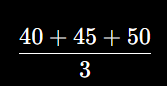

---

## 4. Distance-Weighted KNN

Closer neighbors have greater influence.

Example:

```text
Neighbor A

Distance = 0.5

Neighbor B

Distance = 5
```

Neighbor A receives a larger weight.

This often improves performance when nearby points are much more relevant than farther ones.

---

# Decision Boundary / Model Behavior

Unlike Linear or Logistic Regression, KNN does **not** produce one global equation.

Instead, every prediction depends on the local neighborhood.

Example:

```text
○ ○ ○

      ○

          ●

             ● ●
```

The decision boundary bends around the data.

Characteristics:

* Highly flexible
* Adapts to local patterns
* Can become jagged when K is small
* Becomes smoother as K increases

Effect of K:

### Small K

```text
Complex boundary

Fits noise easily

High Variance
```

### Large K

```text
Smooth boundary

May miss local patterns

High Bias
```

This is one of the most important hyperparameter trade-offs in KNN.

---

# Advantages & Disadvantages

## Advantages

* Extremely simple to understand and implement.
* No expensive training phase.
* Works for both classification and regression.
* Can model highly non-linear decision boundaries.
* Naturally supports multi-class classification.
* Easy to update with new data (just store more samples).

---

## Disadvantages

* Slow during prediction because distances to many training points must be computed.
* Requires storing the entire training dataset.
* Very sensitive to feature scaling.
* Sensitive to irrelevant features.
* Suffers from the curse of dimensionality.
* Choosing the right value of **K** is important.
* Can be affected by noisy data and outliers.

---

# When To Use / Avoid

## Use KNN When

* Dataset is small to medium-sized.
* Decision boundary is non-linear.
* You need a simple baseline model.
* Feature scaling can be applied.
* Memory is not a major constraint.
* Fast training is more important than fast prediction.

---

## Avoid KNN When

* Dataset is very large (prediction becomes slow).
* Number of features is very high (curse of dimensionality).
* Features cannot be meaningfully scaled.
* Low-latency predictions are required (e.g., real-time systems).
* Memory is limited.
* Many irrelevant features are present and cannot be removed.

---

# Key Takeaways

* KNN predicts using the **K nearest training samples**.
* It is a **lazy**, **instance-based** learning algorithm.
* Classification uses **majority voting**.
* Regression uses the **mean or weighted mean**.
* The quality of predictions depends heavily on:

  * Choosing a good value of **K**
  * Selecting an appropriate distance metric
  * Proper feature scaling
  * Having meaningful features
* KNN creates **flexible, non-linear decision boundaries** that adapt to local data.